# Modeling and Evaluation with Walk-Forward Validation

This notebook implements an end-to-end time series forecasting pipeline including:

- Data loading
- Outlier handling
- EDA
- Feature engineering
- Scaling
- Walk-forward validation
- Statistical models (ARIMA, SARIMA, VAR)
- Machine Learning (XGBoost)
- Deep Learning (SimpleRNN, LSTM, GRU)
- Evaluation and visualization

# IMPORTS & CONFIG

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
ư
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.api import VAR
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GRU,
    LSTM,
    SimpleRNN
)

from tensorflow.keras.models import Sequential

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")


# ==========================================
# PROJECT PATHS
# ==========================================

# notebook/
# └── current notebook
#
# project root/
# ├── data/
# ├── outputs/
# ├── plots/
# └── saved_models/

BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data"

OUTPUT_DIR = BASE_DIR / "saved_models"
PLOTS_DIR = BASE_DIR / "plots"
REPORT_DIR = BASE_DIR / "outputs"

TRAIN_PATH = DATA_DIR / "DailyDelhiClimateTrain.csv"
TEST_PATH = DATA_DIR / "DailyDelhiClimateTest.csv"


# ==========================================
# CREATE OUTPUT FOLDERS
# ==========================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)


# ==========================================
# GLOBAL CONFIG
# ==========================================

TARGET_COL = "meantemp"

MULTIVARIATE_COLS = [
    "meantemp",
    "humidity",
    "wind_speed",
    "meanpressure"
]

TIME_STEPS = 7


# ==========================================
# VERIFY DATA PATHS
# ==========================================

print("=" * 60)
print("PROJECT PATH CHECK")
print("=" * 60)

print("BASE_DIR:")
print(BASE_DIR)

print("\nTRAIN_PATH:")
print(TRAIN_PATH)

print("\nTEST_PATH:")
print(TEST_PATH)

print("\nTrain file exists:", TRAIN_PATH.exists())
print("Test file exists :", TEST_PATH.exists())


2026-05-22 19:25:12.005035: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PROJECT PATH CHECK
BASE_DIR:
/Users/user/Final_Project

TRAIN_PATH:
/Users/user/Final_Project/data/DailyDelhiClimateTrain.csv

TEST_PATH:
/Users/user/Final_Project/data/DailyDelhiClimateTest.csv

Train file exists: True
Test file exists : True


# Data Loading and Outlier Handling

In [2]:
def load_data(
    train_path: Path = TRAIN_PATH,
    test_path: Path = TEST_PATH
):

    df_train = pd.read_csv(
        train_path,
        parse_dates=["date"],
        index_col="date"
    )

    df_test = pd.read_csv(
        test_path,
        parse_dates=["date"],
        index_col="date"
    )

    return df_train, df_test


# ==========================================
# OUTLIER HANDLING
# ==========================================

def handle_outliers_iqr(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame
):

    train_clean = df_train.copy()
    test_clean = df_test.copy()

    for col in df_train.columns:

        q1 = df_train[col].quantile(0.25)
        q3 = df_train[col].quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        # TRAIN
        train_clean[col] = np.where(
            (train_clean[col] < lower) |
            (train_clean[col] > upper),
            np.nan,
            train_clean[col]
        )

        # TEST
        test_clean[col] = np.where(
            (test_clean[col] < lower) |
            (test_clean[col] > upper),
            np.nan,
            test_clean[col]
        )

        # INTERPOLATION
        train_clean[col] = (
            train_clean[col]
            .interpolate(method="linear")
            .bfill()
            .ffill()
        )

        test_clean[col] = (
            test_clean[col]
            .interpolate(method="linear")
            .bfill()
            .ffill()
        )

    return train_clean, test_clean


# ==========================================
# EXECUTE DATA PIPELINE
# ==========================================

df_train, df_test = load_data()

df_train, df_test = handle_outliers_iqr(
    df_train,
    df_test
)

print("\n" + "=" * 60)
print("DATA LOADED SUCCESSFULLY")
print("=" * 60)

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

print("\nTrain head:")
display(df_train.head())


DATA LOADED SUCCESSFULLY
Train shape: (1462, 4)
Test shape : (114, 4)

Train head:


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


# TIME SERIES EDA

TRAIN SET SUMMARY


,count,mean,std,min,25%,50%,75%,max
meantemp,1462.0,25.495521,7.348103,6.000000,18.857143,27.714286,31.305804,38.714286
humidity,1462.0,60.785371,16.736246,18.466667,50.375000,62.625000,72.218750,100.000000
wind_speed,1462.0,6.506861,3.913735,0.000000,3.475000,6.064222,9.025000,17.825000
meanpressure,1462.0,1008.249852,7.437428,991.375000,1001.625000,1008.563492,1014.875000,1023.000000




TEST SET SUMMARY


,count,mean,std,min,25%,50%,75%,max
meantemp,114.0,21.713079,6.360072,11.0000,16.437198,19.875000,27.705357,34.500000
humidity,114.0,56.258362,19.068083,17.7500,39.625000,57.750000,71.902778,95.833333
wind_speed,114.0,8.104490,3.487490,1.3875,5.563542,8.069444,10.068750,17.590000
meanpressure,114.0,1012.449807,5.711269,998.6250,1007.767857,1012.961538,1016.861111,1022.809524


MISSING VALUES


,Train Missing,Test Missing
meantemp,0,0
humidity,0,0
wind_speed,0,0
meanpressure,0,0


DATA TYPES


,dtype
meantemp,float64
humidity,float64
wind_speed,float64
meanpressure,float64


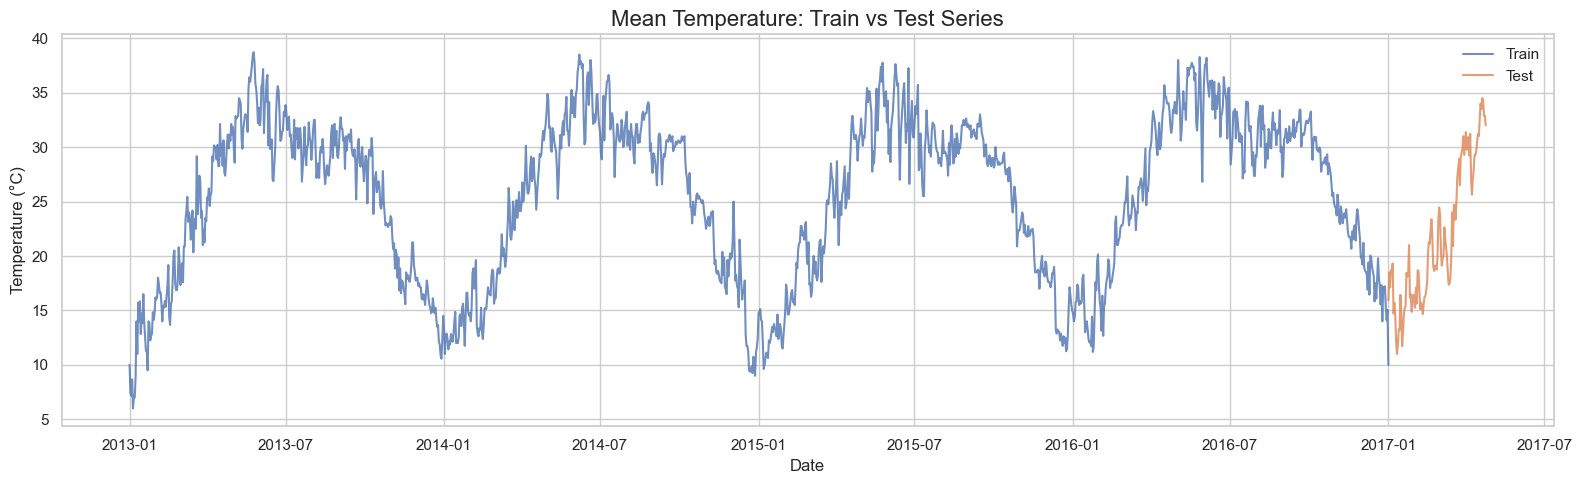

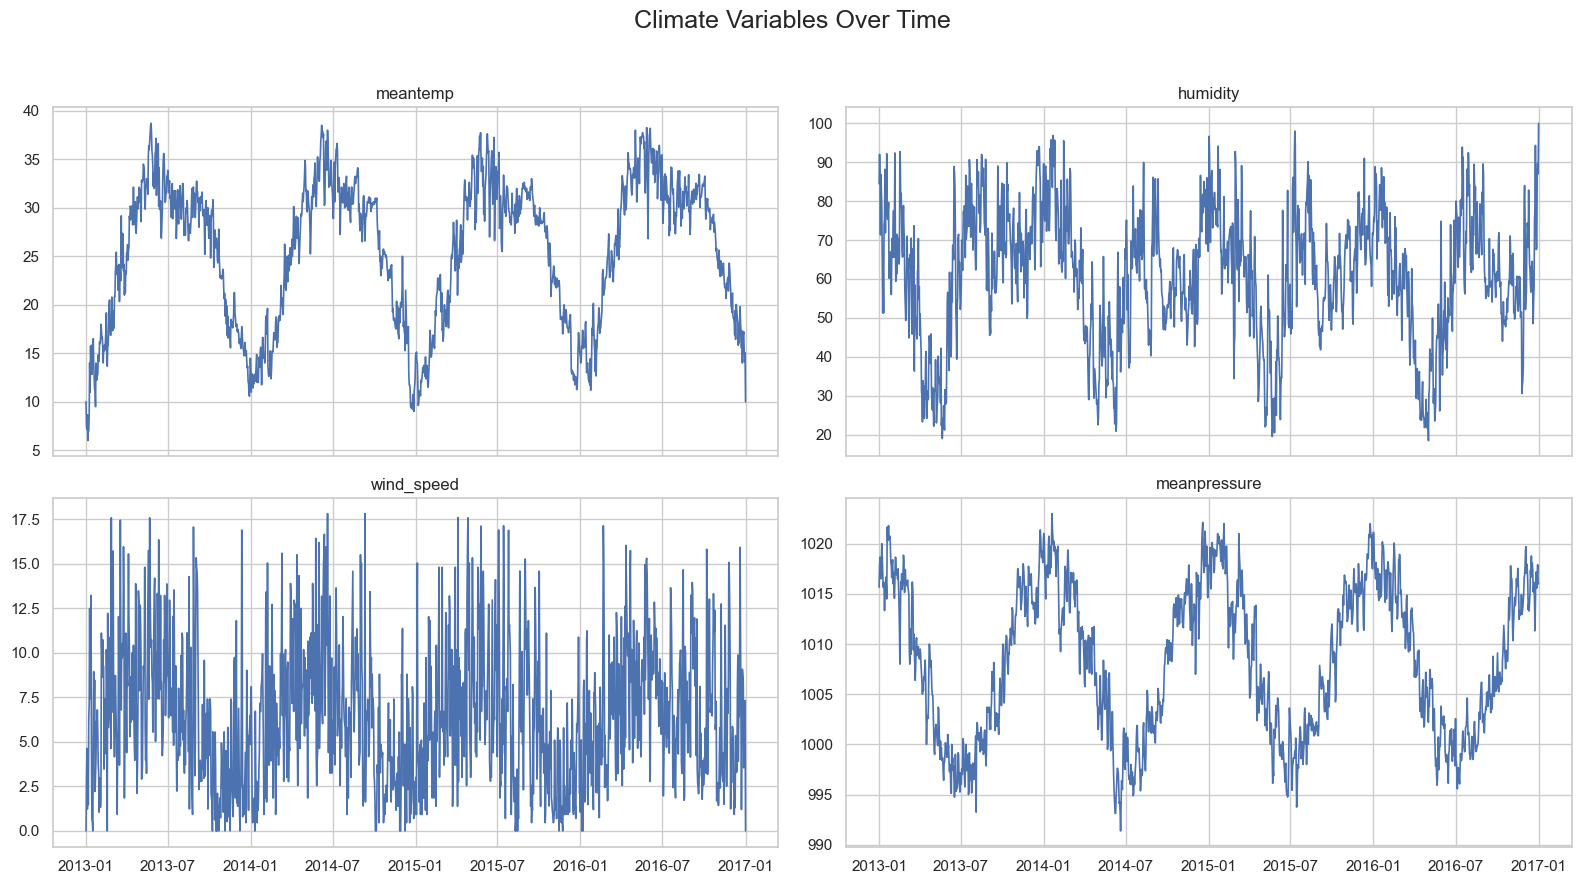

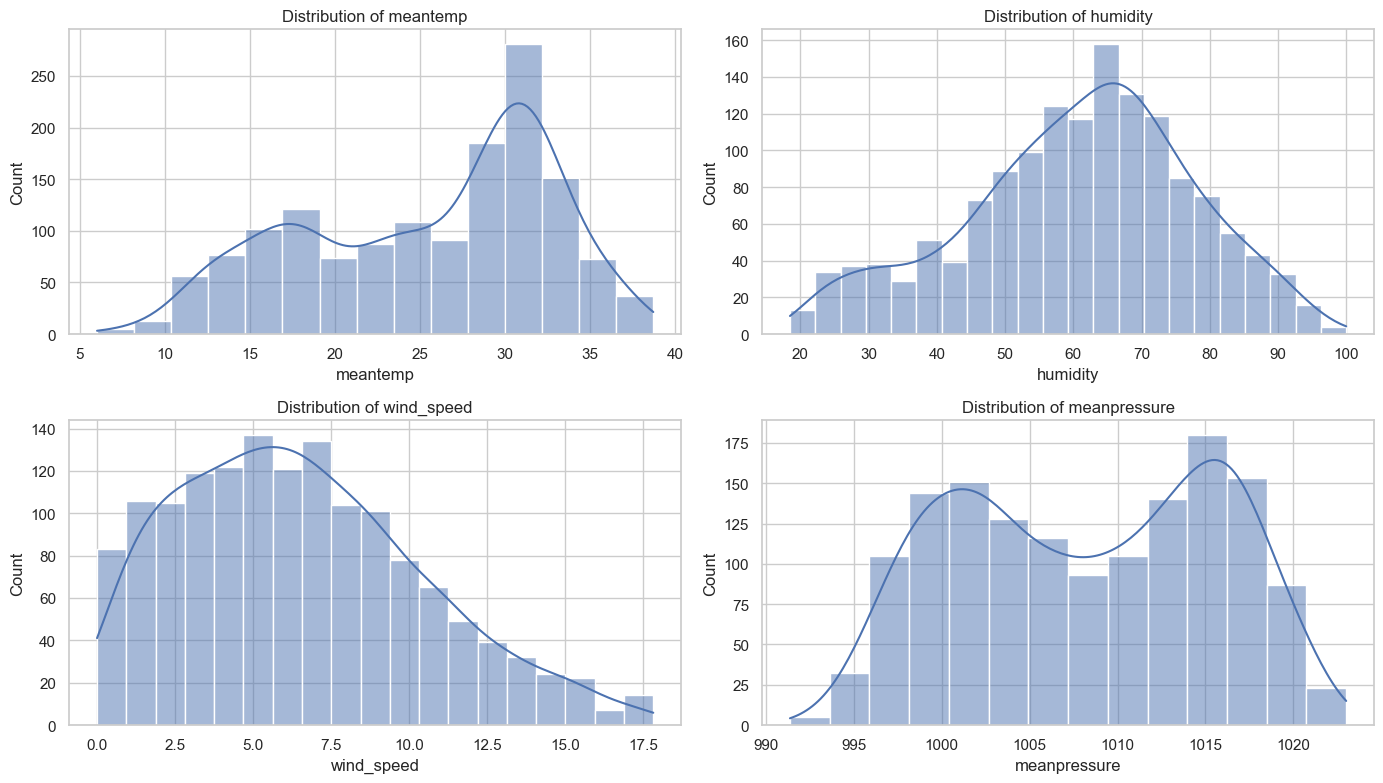

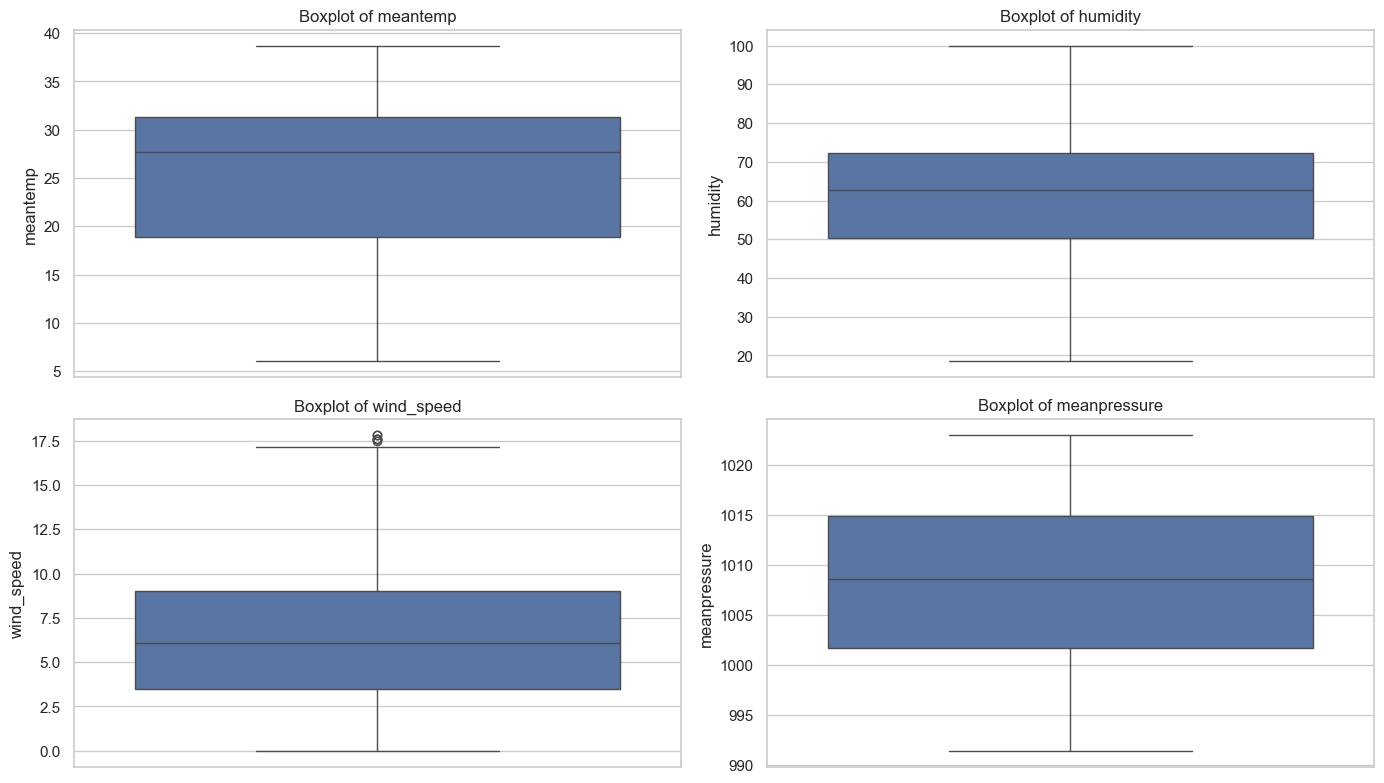

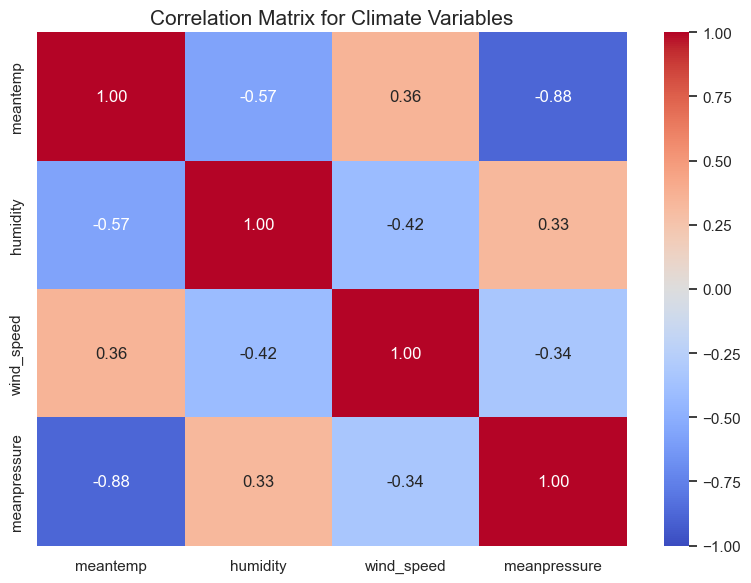

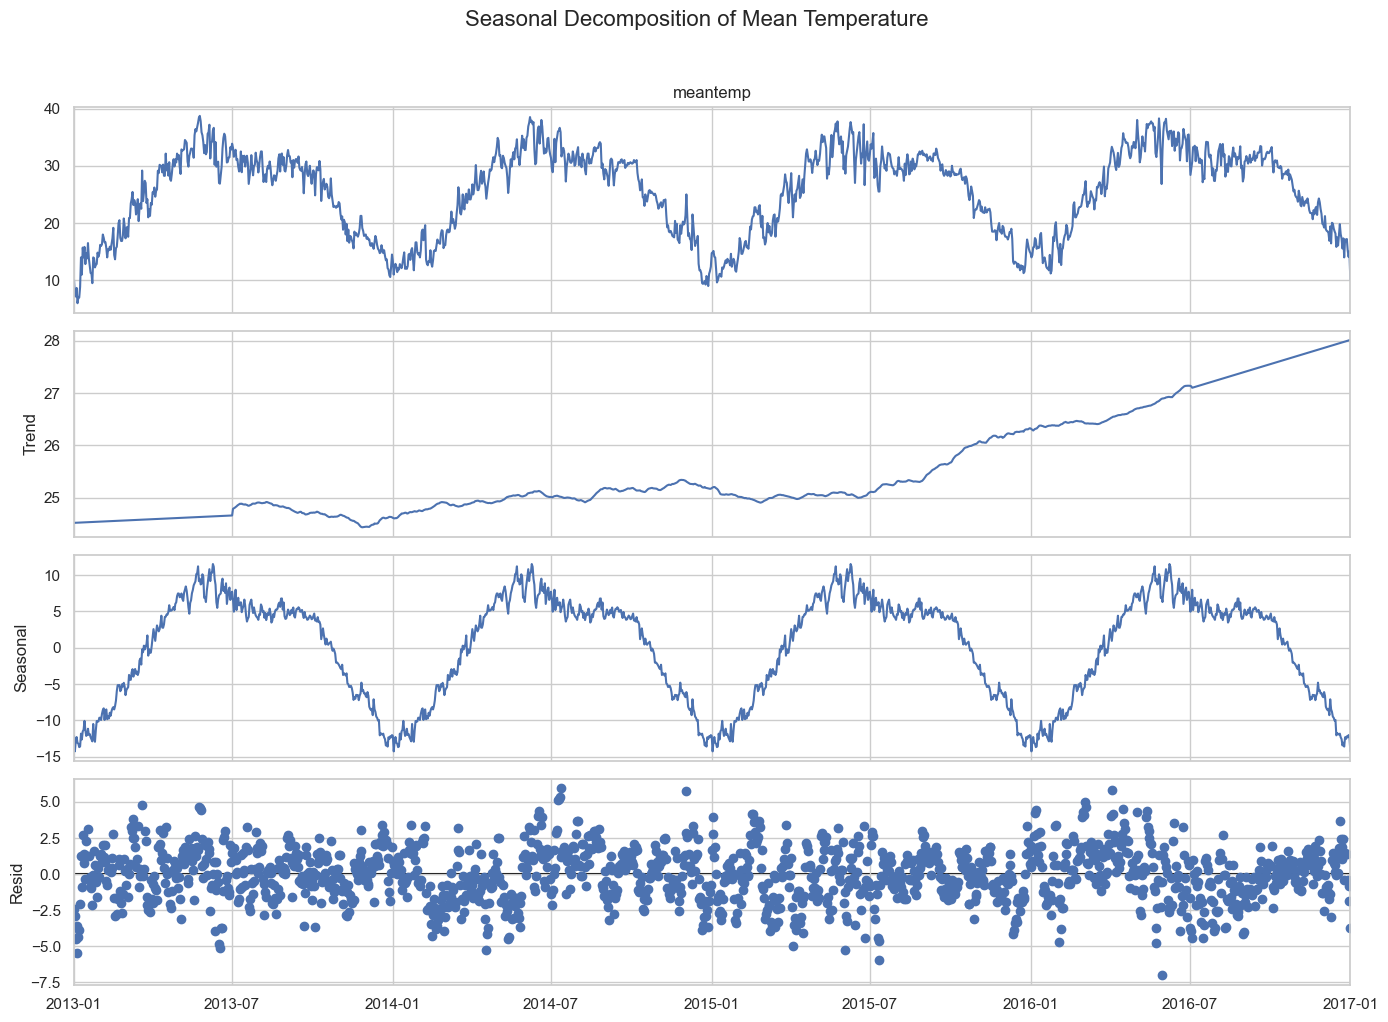

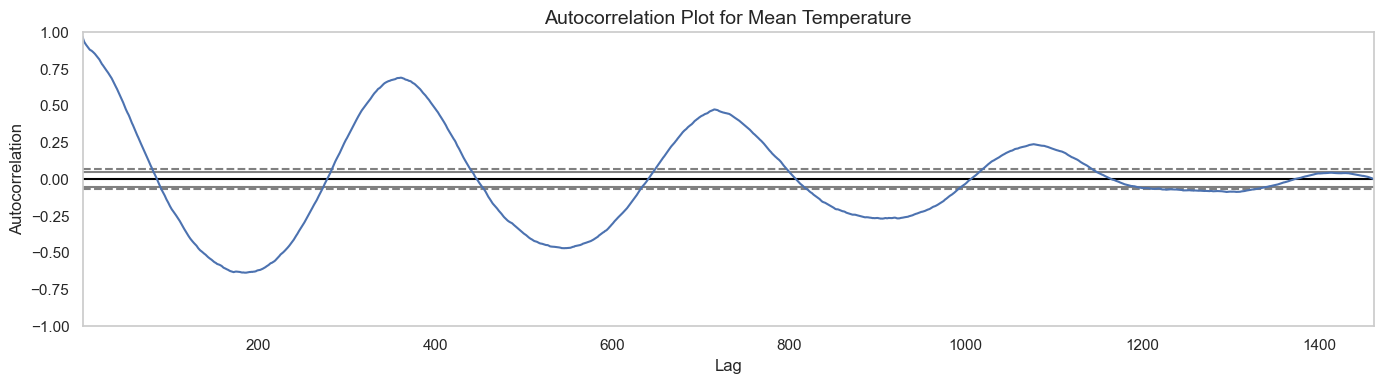

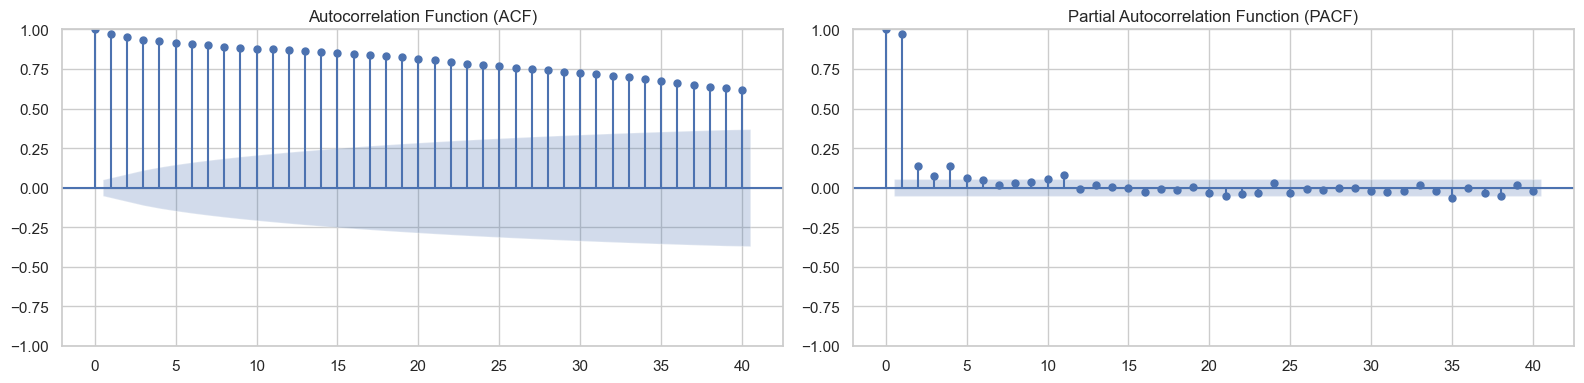

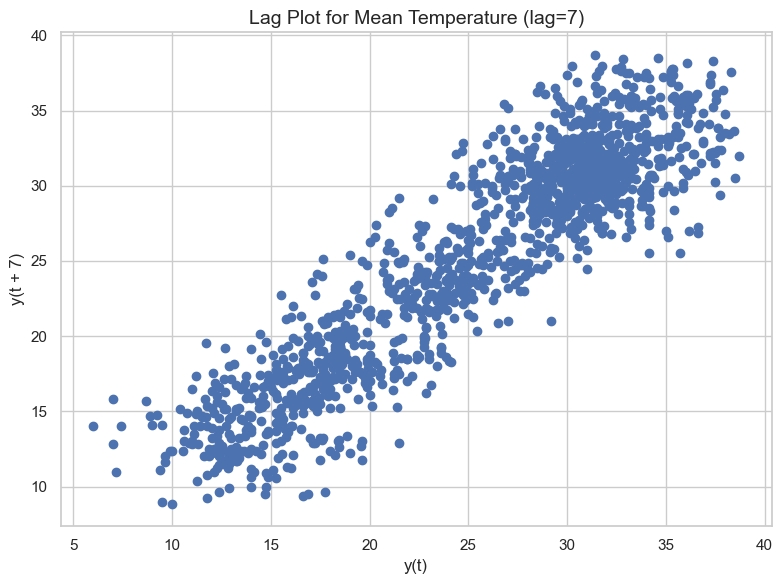

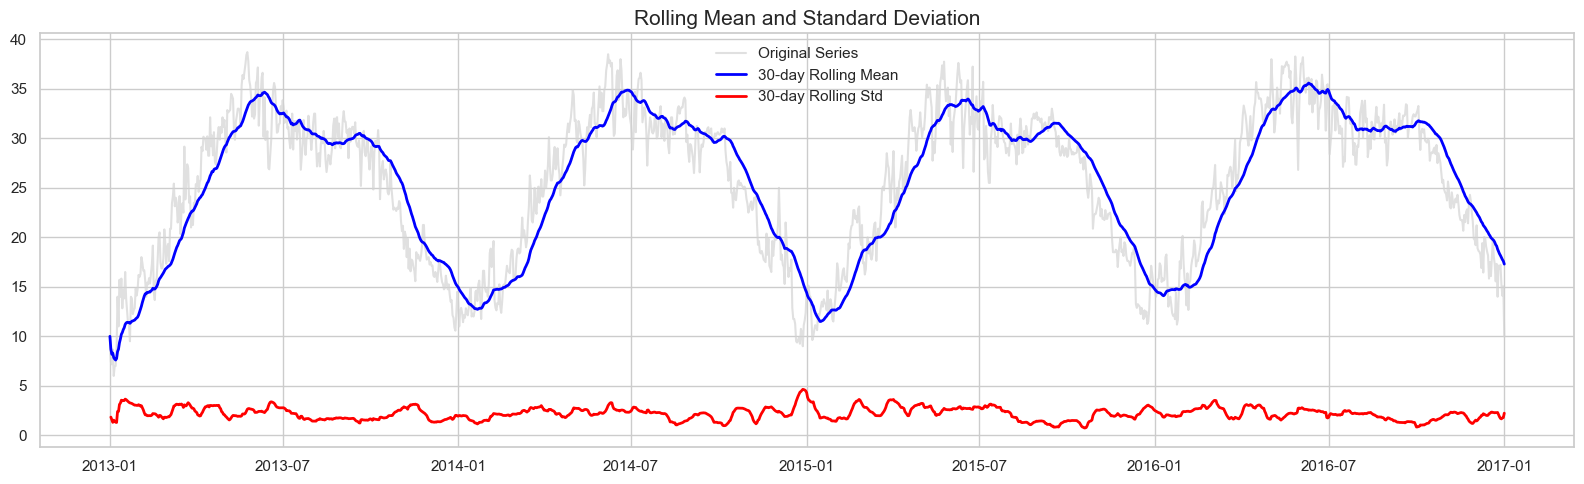

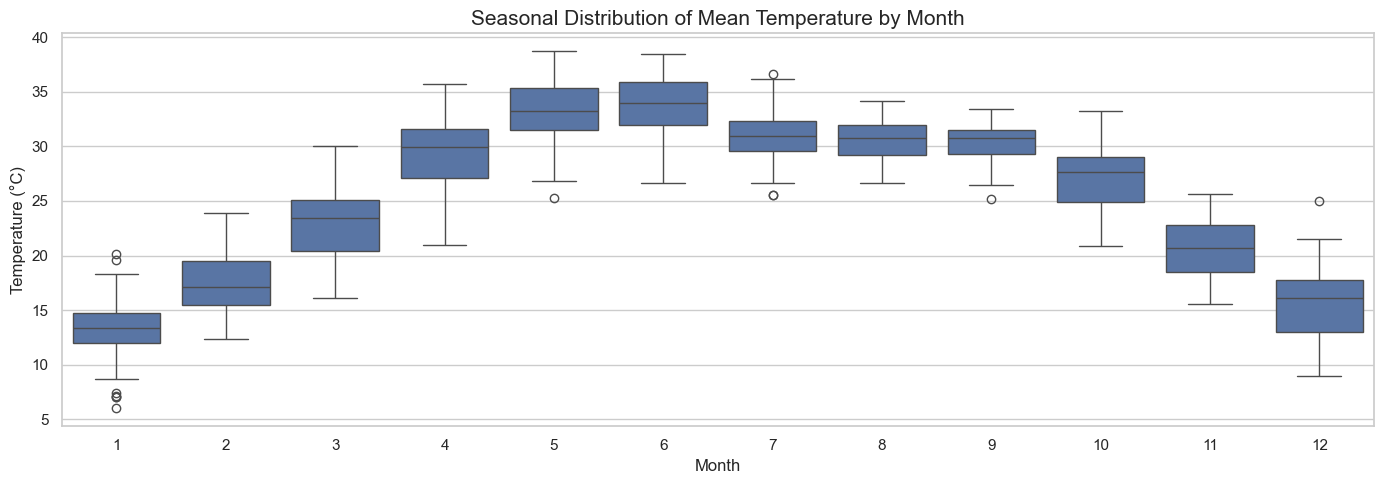

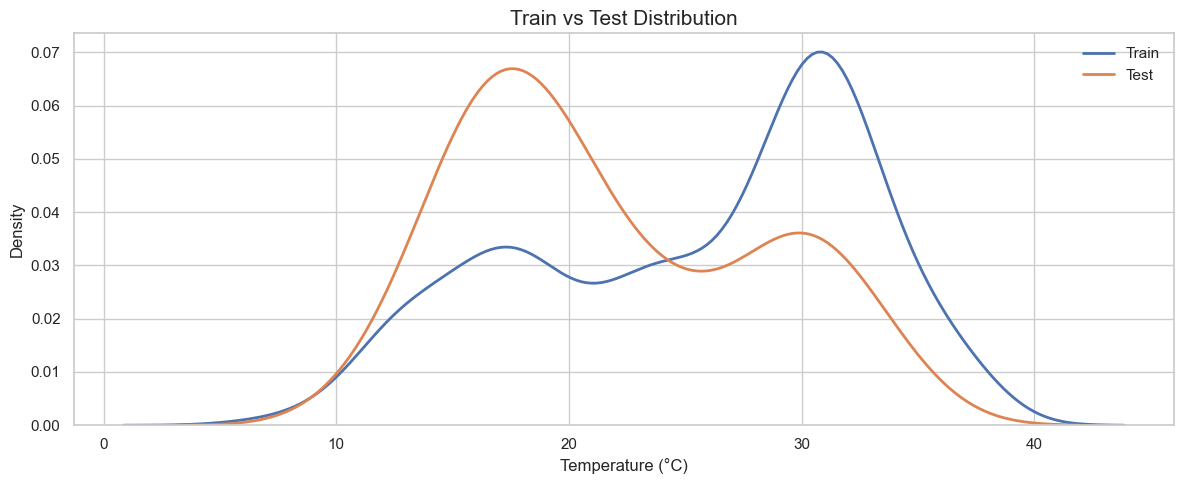

ADF STATIONARITY TEST


,Metric,Value
0,ADF Statistic,-2.021069
1,p-value,0.277412
2,Used Lags,10.000000
3,Number of Observations,1451.000000



Critical Values:
1%: -3.4349
5%: -2.8635
10%: -2.5678

Result: Series is NON-STATIONARY


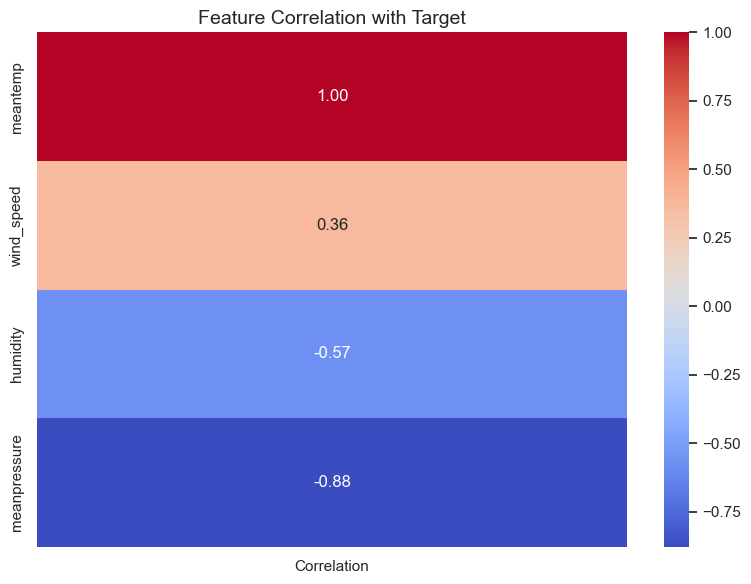

EDA COMPLETED SUCCESSFULLY
Train Shape : (1462, 4)
Test Shape  : (114, 4)

Variables:
- meantemp
- humidity
- wind_speed
- meanpressure

EDA Outputs Generated:
- Summary statistics
- Missing value analysis
- Distribution analysis
- Boxplots
- Time series visualization
- Correlation heatmap
- Seasonal decomposition
- ACF/PACF plots
- Lag analysis
- Rolling statistics
- Monthly seasonality
- Train/Test distribution comparison
- ADF stationarity test


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

print("=" * 60)
print("TRAIN SET SUMMARY")
print("=" * 60)

display(df_train.describe().T)

print("\n")

print("=" * 60)
print("TEST SET SUMMARY")
print("=" * 60)

display(df_test.describe().T)


# ==========================================
# MISSING VALUES CHECK
# ==========================================

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_train = df_train.isnull().sum()
missing_test = df_test.isnull().sum()

missing_df = pd.DataFrame({
    "Train Missing": missing_train,
    "Test Missing": missing_test
})

display(missing_df)


# ==========================================
# DATA TYPES
# ==========================================

print("=" * 60)
print("DATA TYPES")
print("=" * 60)

display(df_train.dtypes.to_frame("dtype"))


# ==========================================
# TARGET SERIES VISUALIZATION
# ==========================================

plt.figure(figsize=(16, 5))

plt.plot(
    df_train.index,
    df_train[TARGET_COL],
    label="Train",
    alpha=0.8,
    linewidth=1.5
)

plt.plot(
    df_test.index,
    df_test[TARGET_COL],
    label="Test",
    alpha=0.8,
    linewidth=1.5
)

plt.title(
    "Mean Temperature: Train vs Test Series",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()

plt.tight_layout()
plt.show()


# ==========================================
# MULTIVARIATE TIME SERIES
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 9),
    sharex=True
)

axes = axes.flatten()

for i, col in enumerate(MULTIVARIATE_COLS):

    axes[i].plot(
        df_train.index,
        df_train[col],
        linewidth=1.2
    )

    axes[i].set_title(col)

plt.suptitle(
    "Climate Variables Over Time",
    fontsize=18
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()


# ==========================================
# DISTRIBUTION PLOTS
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 8)
)

axes = axes.flatten()

for i, col in enumerate(MULTIVARIATE_COLS):

    sns.histplot(
        df_train[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


# ==========================================
# BOXPLOTS
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 8)
)

axes = axes.flatten()

for i, col in enumerate(MULTIVARIATE_COLS):

    sns.boxplot(
        y=df_train[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()


# ==========================================
# CORRELATION MATRIX
# ==========================================

corr_matrix = df_train[MULTIVARIATE_COLS].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title(
    "Correlation Matrix for Climate Variables",
    fontsize=15
)

plt.tight_layout()
plt.show()


# ==========================================
# SEASONAL DECOMPOSITION
# ==========================================

decomposition = seasonal_decompose(
    df_train[TARGET_COL],
    period=365,
    model="additive",
    extrapolate_trend="freq"
)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.suptitle(
    "Seasonal Decomposition of Mean Temperature",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


# ==========================================
# AUTOCORRELATION PLOT
# ==========================================

plt.figure(figsize=(14, 4))

pd.plotting.autocorrelation_plot(
    df_train[TARGET_COL]
)

plt.title(
    "Autocorrelation Plot for Mean Temperature",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ==========================================
# ACF / PACF
# ==========================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 4)
)

plot_acf(
    df_train[TARGET_COL],
    lags=40,
    ax=axes[0]
)

plot_pacf(
    df_train[TARGET_COL],
    lags=40,
    ax=axes[1]
)

axes[0].set_title("Autocorrelation Function (ACF)")
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()


# ==========================================
# LAG PLOT
# ==========================================

plt.figure(figsize=(8, 6))

pd.plotting.lag_plot(
    df_train[TARGET_COL],
    lag=7
)

plt.title(
    "Lag Plot for Mean Temperature (lag=7)",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ==========================================
# ROLLING STATISTICS
# ==========================================

rolling_mean = (
    df_train[TARGET_COL]
    .rolling(window=30, min_periods=1)
    .mean()
)

rolling_std = (
    df_train[TARGET_COL]
    .rolling(window=30, min_periods=1)
    .std()
)

plt.figure(figsize=(16, 5))

plt.plot(
    df_train[TARGET_COL],
    color="lightgray",
    alpha=0.7,
    label="Original Series"
)

plt.plot(
    rolling_mean,
    color="blue",
    linewidth=2,
    label="30-day Rolling Mean"
)

plt.plot(
    rolling_std,
    color="red",
    linewidth=2,
    label="30-day Rolling Std"
)

plt.title(
    "Rolling Mean and Standard Deviation",
    fontsize=15
)

plt.legend()

plt.tight_layout()
plt.show()


# ==========================================
# MONTHLY SEASONALITY
# ==========================================

monthly_df = df_train.copy()

monthly_df["month"] = monthly_df.index.month

plt.figure(figsize=(14, 5))

sns.boxplot(
    x="month",
    y=TARGET_COL,
    data=monthly_df
)

plt.title(
    "Seasonal Distribution of Mean Temperature by Month",
    fontsize=15
)

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()


# ==========================================
# TRAIN VS TEST DISTRIBUTION
# ==========================================

plt.figure(figsize=(12, 5))

sns.kdeplot(
    df_train[TARGET_COL],
    label="Train",
    linewidth=2
)

sns.kdeplot(
    df_test[TARGET_COL],
    label="Test",
    linewidth=2
)

plt.title(
    "Train vs Test Distribution",
    fontsize=15
)

plt.xlabel("Temperature (°C)")

plt.legend()

plt.tight_layout()
plt.show()


# ==========================================
# STATIONARITY TEST (ADF)
# ==========================================

print("=" * 60)
print("ADF STATIONARITY TEST")
print("=" * 60)

adf_result = adfuller(df_train[TARGET_COL])

adf_output = pd.DataFrame({
    "Metric": [
        "ADF Statistic",
        "p-value",
        "Used Lags",
        "Number of Observations"
    ],
    "Value": [
        adf_result[0],
        adf_result[1],
        adf_result[2],
        adf_result[3]
    ]
})

display(adf_output)

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nResult: Series is STATIONARY")
else:
    print("\nResult: Series is NON-STATIONARY")


# ==========================================
# FEATURE CORRELATION WITH TARGET
# ==========================================

feature_corr = (
    df_train.corr()[TARGET_COL]
    .sort_values(ascending=False)
    .to_frame("Correlation")
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    feature_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Feature Correlation with Target",
    fontsize=14
)

plt.tight_layout()
plt.show()


# ==========================================
# SUMMARY
# ==========================================

print("=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"Train Shape : {df_train.shape}")
print(f"Test Shape  : {df_test.shape}")

print("\nVariables:")
for col in MULTIVARIATE_COLS:
    print(f"- {col}")

print("\nEDA Outputs Generated:")
print("- Summary statistics")
print("- Missing value analysis")
print("- Distribution analysis")
print("- Boxplots")
print("- Time series visualization")
print("- Correlation heatmap")
print("- Seasonal decomposition")
print("- ACF/PACF plots")
print("- Lag analysis")
print("- Rolling statistics")
print("- Monthly seasonality")
print("- Train/Test distribution comparison")
print("- ADF stationarity test")

# Feature Engineering and Scaling

In [4]:
def create_features(df: pd.DataFrame):

    df = df.copy()

    df["year"] = df.index.year
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["dayofweek"] = df.index.dayofweek
    df["quarter"] = df.index.quarter

    df["meantemp_lag_1"] = df[TARGET_COL].shift(1)
    df["meantemp_lag_2"] = df[TARGET_COL].shift(2)
    df["meantemp_lag_7"] = df[TARGET_COL].shift(7)

    df["roll_mean_3"] = (
        df[TARGET_COL]
        .shift(1)
        .rolling(3)
        .mean()
    )

    df["roll_mean_7"] = (
        df[TARGET_COL]
        .shift(1)
        .rolling(7)
        .mean()
    )

    df["roll_std_7"] = (
        df[TARGET_COL]
        .shift(1)
        .rolling(7)
        .std()
    )

    return df.dropna()


df_train_fe = create_features(df_train)
df_test_fe = create_features(df_test)

feature_cols = [
    col for col in df_train_fe.columns
    if col != TARGET_COL
]

X_train_raw = df_train_fe[feature_cols]
y_train_raw = df_train_fe[TARGET_COL]

X_test_raw = df_test_fe[feature_cols]
y_test_raw = df_test_fe[TARGET_COL]


scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled = scaler_X.transform(X_test_raw)

y_train_scaled = scaler_y.fit_transform(
    y_train_raw.values.reshape(-1, 1)
)

y_test_scaled = scaler_y.transform(
    y_test_raw.values.reshape(-1, 1)
)

print("Feature engineering completed")

Feature engineering completed


# Walk-Forward Validation for Statistical Models

In [5]:
def walk_forward_statistical(df_train, df_test):

    history_target = df_train[TARGET_COL].tolist()

    history_multivariate = (
        df_train[MULTIVARIATE_COLS]
        .values
        .tolist()
    )

    arima_preds = []
    sarima_preds = []
    var_preds = []

    for t in range(len(df_test)):

        if t >= TIME_STEPS:

            # ARIMA
            arima_model = ARIMA(
                history_target,
                order=(7, 1, 1)
            )

            arima_fit = arima_model.fit()

            arima_preds.append(
                arima_fit.forecast()[0]
            )

            # SARIMA
            sarima_model = SARIMAX(
                history_target,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7)
            )

            sarima_fit = sarima_model.fit(
                disp=False
            )

            sarima_preds.append(
                sarima_fit.forecast()[0]
            )

            # VAR
            var_model = VAR(
                np.array(history_multivariate)
            )

            var_fit = var_model.fit(maxlags=7)

            var_forecast = var_fit.forecast(
                y=np.array(history_multivariate)[
                    -var_fit.k_ar:
                ],
                steps=1
            )

            var_preds.append(
                var_forecast[0][0]
            )

        history_target.append(
            df_test.iloc[t][TARGET_COL]
        )

        history_multivariate.append(
            df_test.iloc[t][MULTIVARIATE_COLS]
            .values
            .tolist()
        )

    return {
        "ARIMA": np.array(arima_preds),
        "SARIMA": np.array(sarima_preds),
        "VAR": np.array(var_preds)
    }


classical_predictions = walk_forward_statistical(
    df_train,
    df_test
)

print("Statistical models completed")

Statistical models completed


## Machine Learning and Deep Learning Models

In [6]:
def create_3d_dataset(X, y, time_steps=TIME_STEPS):

    Xs = []
    ys = []

    for i in range(len(X) - time_steps):

        Xs.append(
            X[i:i + time_steps]
        )

        ys.append(
            y[i + time_steps]
        )

    return np.array(Xs), np.array(ys)


X_train_3d, y_train_3d = create_3d_dataset(
    X_train_scaled,
    y_train_scaled
)

X_test_3d, y_test_3d = create_3d_dataset(
    X_test_scaled,
    y_test_scaled
)


# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(
    X_train_raw.iloc[TIME_STEPS:],
    y_train_raw.iloc[TIME_STEPS:]
)

xgb_predictions = xgb_model.predict(
    X_test_raw.iloc[TIME_STEPS:]
)


def build_dl_models(input_shape):

    return {

        "SimpleRNN": Sequential([
            SimpleRNN(
                32,
                activation="relu",
                input_shape=input_shape
            ),
            Dropout(0.1),
            Dense(1)
        ]),

        "LSTM": Sequential([
            LSTM(
                50,
                activation="relu",
                input_shape=input_shape
            ),
            Dropout(0.1),
            Dense(1)
        ]),

        "GRU": Sequential([
            GRU(
                50,
                activation="relu",
                input_shape=input_shape
            ),
            Dropout(0.1),
            Dense(1)
        ])
    }


input_shape = (
    X_train_3d.shape[1],
    X_train_3d.shape[2]
)

dl_models = build_dl_models(input_shape)

dl_predictions = {}

for name, model in dl_models.items():

    print(f"Training {name}")

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    early_stop = EarlyStopping(
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_train_3d,
        y_train_3d,
        epochs=25,
        batch_size=32,
        validation_split=0.1,
        verbose=0,
        callbacks=[early_stop]
    )

    preds_scaled = model.predict(
        X_test_3d,
        verbose=0
    )

    preds = scaler_y.inverse_transform(
        preds_scaled
    ).flatten()

    dl_predictions[name] = preds

print("Deep learning completed")

Training SimpleRNN
Training LSTM
Training GRU
Deep learning completed


# Evaluation and Export

In [8]:
# ==========================================
# SAVE PLOT
# ==========================================

def save_plot(filename):

    plt.tight_layout()

    plt.savefig(
        PLOTS_DIR / filename,
        bbox_inches="tight"
    )

    plt.close()


# ==========================================
# EVALUATION METRICS
# ==========================================

def evaluate_predictions(predictions, actual):

    rows = []

    for name, preds in predictions.items():

        if name == "Actual":
            continue

        rows.append({

            "Model": name,

            "MAE": mean_absolute_error(
                actual,
                preds
            ),

            "RMSE": np.sqrt(
                mean_squared_error(
                    actual,
                    preds
                )
            ),

            "R2": r2_score(
                actual,
                preds
            )
        })

    leaderboard = (
        pd.DataFrame(rows)
        .sort_values("RMSE")
        .reset_index(drop=True)
    )

    return leaderboard


# ==========================================
# SAVE MODELS
# ==========================================

def save_model_objects(objects):

    for name, obj in objects.items():

        if obj is None:
            continue

        if name in [
            "SimpleRNN",
            "LSTM",
            "GRU"
        ]:

            obj.save(
                OUTPUT_DIR / f"{name}.h5"
            )

        else:

            joblib.dump(
                obj,
                OUTPUT_DIR / f"{name}.pkl"
            )


# ==========================================
# FORECAST PLOT
# ==========================================

def plot_forecasts(eval_index, predictions):

    plt.figure(figsize=(16, 8))

    plt.plot(
        eval_index,
        predictions["Actual"],
        label="Actual",
        linewidth=3,
        color="black"
    )

    for name, preds in predictions.items():

        if name == "Actual":
            continue

        plt.plot(
            eval_index,
            preds,
            label=name,
            linewidth=1.8
        )

    plt.title(
        "Forecast Comparison",
        fontsize=16
    )

    plt.xlabel("Date")
    plt.ylabel("Mean Temperature")

    plt.legend()

    save_plot(
        "05_forecast_comparison.png"
    )


# ==========================================
# RESIDUAL DIAGNOSTICS
# ==========================================

def plot_model_diagnostics(
    eval_index,
    actual,
    predictions
):

    for name, preds in predictions.items():

        if name == "Actual":
            continue

        residuals = actual - preds

        # Residual line plot
        plt.figure(figsize=(14, 4))

        plt.plot(
            eval_index,
            residuals,
            linewidth=1.5
        )

        plt.axhline(
            0,
            linestyle="--",
            color="black"
        )

        plt.title(
            f"{name} Residuals"
        )

        plt.xlabel("Date")
        plt.ylabel("Residual")

        save_plot(
            f"06_{name.lower()}_residuals.png"
        )

        # Residual distribution
        plt.figure(figsize=(8, 4))

        sns.histplot(
            residuals,
            kde=True
        )

        plt.title(
            f"{name} Residual Distribution"
        )

        save_plot(
            f"07_{name.lower()}_distribution.png"
        )


# ==========================================
# ALIGN PREDICTION LENGTHS
# ==========================================

prediction_lengths = [

    len(classical_predictions["ARIMA"]),
    len(classical_predictions["SARIMA"]),
    len(classical_predictions["VAR"]),
    len(xgb_predictions)

]

prediction_lengths.extend([

    len(preds)
    for preds in dl_predictions.values()

])

min_length = min(prediction_lengths)

print("=" * 60)
print("ALIGNMENT CHECK")
print("=" * 60)

print("Minimum prediction length:", min_length)


# ==========================================
# EVALUATION INDEX
# ==========================================

eval_index = df_test.index[-min_length:]

actual_values = (

    df_test[TARGET_COL]
    .iloc[-min_length:]
    .values

)


# ==========================================
# ALIGN ALL PREDICTIONS
# ==========================================

predictions = {

    "Actual":
        actual_values,

    "ARIMA":
        classical_predictions["ARIMA"][-min_length:],

    "SARIMA":
        classical_predictions["SARIMA"][-min_length:],

    "VAR":
        classical_predictions["VAR"][-min_length:],

    "XGBoost":
        xgb_predictions[-min_length:]
}


for name, preds in dl_predictions.items():

    predictions[name] = preds[-min_length:]


# ==========================================
# DEBUG LENGTH CHECK
# ==========================================

print("\nPrediction lengths:")

for name, preds in predictions.items():

    print(f"{name}: {len(preds)}")


# ==========================================
# EVALUATE MODELS
# ==========================================

leaderboard = evaluate_predictions(
    predictions,
    actual_values
)

print("\n")
print("=" * 60)
print("MODEL LEADERBOARD")
print("=" * 60)

display(leaderboard)


# ==========================================
# PLOTS
# ==========================================

plot_forecasts(
    eval_index,
    predictions
)

plot_model_diagnostics(
    eval_index,
    actual_values,
    predictions
)


# ==========================================
# SAVE FORECASTS
# ==========================================

forecast_df = pd.DataFrame({

    "date":
        eval_index,

    "Actual":
        actual_values
})


for name, preds in predictions.items():

    if name == "Actual":
        continue

    forecast_df[name] = preds


forecast_df.to_csv(

    REPORT_DIR / "forecast_predictions.csv",

    index=False

)


# ==========================================
# SAVE LEADERBOARD
# ==========================================

leaderboard.to_csv(

    REPORT_DIR / "leaderboard.csv",

    index=False

)


# ==========================================
# SAVE MODELS
# ==========================================

save_model_objects({

    "XGBoost": xgb_model,

    **dl_models

})


# ==========================================
# FINAL OUTPUT
# ==========================================

print("\n")
print("=" * 60)
print("ALL OUTPUTS SAVED SUCCESSFULLY")
print("=" * 60)

print("Forecast CSV:")
print(REPORT_DIR / "forecast_predictions.csv")

print("\nLeaderboard CSV:")
print(REPORT_DIR / "leaderboard.csv")

print("\nPlots Directory:")
print(PLOTS_DIR)

print("\nSaved Models Directory:")
print(OUTPUT_DIR)

ALIGNMENT CHECK
Minimum prediction length: 100

Prediction lengths:
Actual: 100
ARIMA: 100
SARIMA: 100
VAR: 100
XGBoost: 100
SimpleRNN: 100
LSTM: 100
GRU: 100


MODEL LEADERBOARD


,Model,MAE,RMSE,R2
0,VAR,1.323831,1.652767,0.928362
1,SARIMA,1.318017,1.656428,0.928045
2,ARIMA,1.346038,1.681766,0.925827
3,XGBoost,1.315093,1.722260,0.922212
4,LSTM,2.047260,2.476707,0.839133
5,GRU,2.008808,2.484000,0.838184
6,SimpleRNN,2.182584,2.560582,0.828053




ALL OUTPUTS SAVED SUCCESSFULLY
Forecast CSV:
/Users/user/Final_Project/outputs/forecast_predictions.csv

Leaderboard CSV:
/Users/user/Final_Project/outputs/leaderboard.csv

Plots Directory:
/Users/user/Final_Project/plots

Saved Models Directory:
/Users/user/Final_Project/saved_models
